# Notebook 16: Richards Equation — Groundwater Flow

This notebook introduces the Richards equation for variably-saturated
porous media flow. We solve a steady-state drainage problem in a
vertical soil column and validate the numerical solution against an
exact analytical benchmark.

## Key Concepts

- Richards equation — nonlinear PDE for unsaturated flow
- Gardner exponential conductivity model
- Analytical steady-state solution with gravity
- Darcy velocity field

## The Richards Equation

Water movement in unsaturated soil is governed by the Richards
equation (Richards, 1931). Three equivalent forms exist:

| Form | Storage term | Flux term | Notes |
|------|-------------|-----------|-------|
| Head-based ($\psi$) | $C(\psi)\,\partial\psi/\partial t$ | $\nabla\cdot[K(\psi)(\nabla\psi - \mathbf{s})]$ | Simple, but poor mass balance |
| Moisture-based ($\theta$) | $\partial\theta/\partial t$ | $\nabla\cdot[D(\theta)\nabla\theta]$ | Conservative, but $D(\theta)$ singular at saturation |
| **Mixed** | $\partial\theta/\partial t$ | $\nabla\cdot[K(\psi)(\nabla\psi - \mathbf{s})]$ | Conservative and well-behaved |

The **mixed form** (Celia et al., 1990) is generally preferred because
writing the storage as $\partial\theta/\partial t$ guarantees mass
conservation in the discrete system — the head-based form
$C(\psi)\,\partial\psi/\partial t$ introduces balance errors because the
discrete chain rule $C(\psi)\Delta\psi \neq \Delta\theta$ when $C$ varies
sharply across a timestep.

$$\frac{\partial \theta}{\partial t}
  - \nabla\cdot\bigl[K(\psi)\,(\nabla\psi - \mathbf{s})\bigr] = f$$

where
- $\psi$ is the **pressure head** (negative in unsaturated soil),
- $\theta(\psi)$ is the **volumetric water content**,
- $K(\psi)$ is the **hydraulic conductivity** (decreases as soil dries out),
- $\mathbf{s} = [0, -1]^T$ represents **gravity** (pointing downward),
- $f$ is any source/sink.

The Underworld solver uses this mixed form when `water_content` is set
— discretising the storage term as
$(\theta(\psi^{n+1}) - \theta(\psi^n))/\Delta t$.
The Jacobian $\partial\theta/\partial\psi = C(\psi)$ is computed
automatically by PETSc. For steady-state problems (where
$\partial/\partial t = 0$) the forms are all identical.

## Gardner Exponential Model

The **Gardner (1958)** model uses an exponential relationship for
hydraulic conductivity:

$$K(\psi) = K_s\,e^{\alpha\psi}, \qquad \psi < 0$$

This is simpler than the Van Genuchten model and, crucially,
admits an **exact analytical solution** for the steady-state
Richards equation with gravity.

The substitution $u = e^{\alpha\psi}$ linearises the ODE, giving
the exact pressure head profile:

$$\psi(y) = \frac{1}{\alpha}\,\ln\!\Bigl[
    \bigl(u_0 - q^*\bigr)\,e^{-\alpha y} + q^*
\Bigr]$$

where $u_0 = e^{\alpha\psi_0}$, $u_L = e^{\alpha\psi_L}$, and
$q^* = q/K_s = (u_L - u_0\,e^{-\alpha L})/(1 - e^{-\alpha L})$.

In [1]:
import numpy as np
import sympy
import underworld3 as uw
import matplotlib.pyplot as plt

from underworld3.utilities.retention_curves import (
    gardner_K,
    gardner_theta,
    gardner_steady_state_psi,
)

### Configurable parameters

Default values are defined as named constants below. From the
command line, override them with PETSc-style flags:

```bash
python script.py -uw_Ks "5e-5 m/s" -uw_alpha "2.0 1/m"
```

In [2]:
# --- Default values (edit these in a notebook) ---
COLUMN_HEIGHT = 1.0     # m   — soil column height
COLUMN_WIDTH  = 0.1     # m   — narrow (≈ 1-D)
RES           = 32      #     — vertical elements
KS            = 1e-4    # m/s — saturated hydraulic conductivity
ALPHA_G       = 3.5     # 1/m — Gardner sorptive number
THETA_R       = 0.05    #     — residual water content
THETA_S       = 0.40    #     — saturated water content
PSI_TOP       = -0.5    # m   — pressure head at top
PSI_BOTTOM    = -3.0    # m   — pressure head at bottom

In [3]:
# Named expressions for display
Ks      = uw.expression(r"K_s",      uw.quantity(KS, "m/s"),   "saturated conductivity")
alpha_g = uw.expression(r"\alpha",   uw.quantity(ALPHA_G, "1/m"), "Gardner sorptive number")
theta_r = uw.expression(r"\theta_r", THETA_R,  "residual water content")
theta_s = uw.expression(r"\theta_s", THETA_S,  "saturated water content")

Ks

<IPython.core.display.Latex object>

## Retention Curves

Let’s visualise how hydraulic conductivity and water content
change with pressure head for these Gardner parameters.

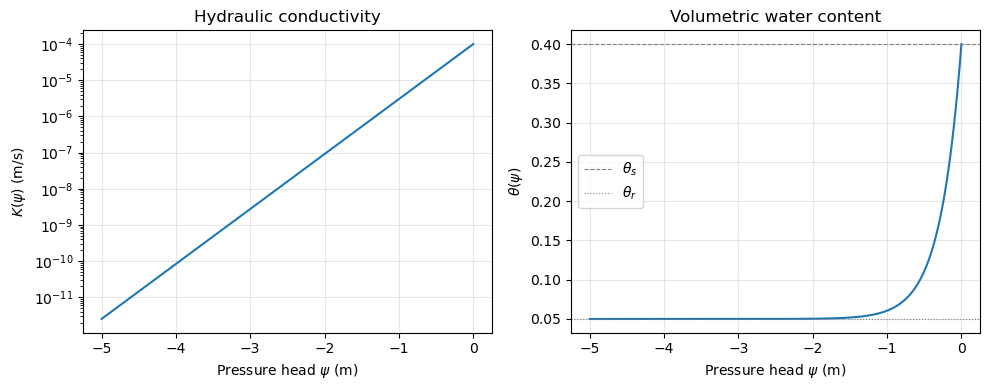

In [4]:
psi_range = np.linspace(-5, 0, 200)

K_vals = KS * np.exp(ALPHA_G * psi_range)
K_vals[psi_range >= 0] = KS

theta_vals = THETA_R + (THETA_S - THETA_R) * np.exp(ALPHA_G * psi_range)
theta_vals[psi_range >= 0] = THETA_S

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.semilogy(psi_range, K_vals)
ax1.set_xlabel(r"Pressure head $\psi$ (m)")
ax1.set_ylabel(r"$K(\psi)$ (m/s)")
ax1.set_title("Hydraulic conductivity")
ax1.grid(True, alpha=0.3)

ax2.plot(psi_range, theta_vals)
ax2.set_xlabel(r"Pressure head $\psi$ (m)")
ax2.set_ylabel(r"$\theta(\psi)$")
ax2.set_title("Volumetric water content")
ax2.axhline(THETA_S, color="grey", ls="--", lw=0.8, label=r"$\theta_s$")
ax2.axhline(THETA_R, color="grey", ls=":",  lw=0.8, label=r"$\theta_r$")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Analytical Solution

For a column of height $L$ with boundary conditions
$\psi(0) = \psi_\text{bottom}$ and $\psi(L) = \psi_\text{top}$,
the exact steady-state profile is given by
`gardner_steady_state_psi`.

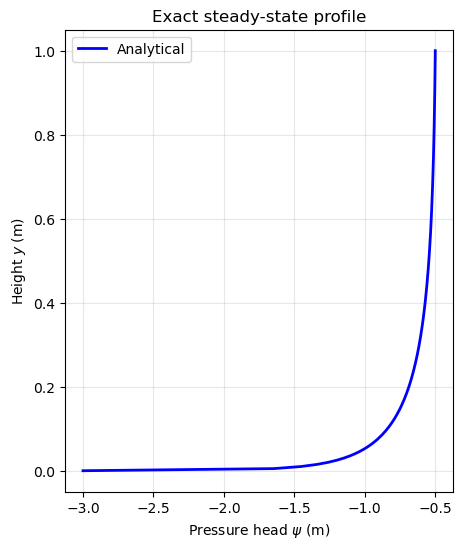

In [5]:
y_exact = np.linspace(0, COLUMN_HEIGHT, 200)
psi_exact = gardner_steady_state_psi(
    y_exact,
    psi_0=PSI_BOTTOM,
    psi_L=PSI_TOP,
    L=COLUMN_HEIGHT,
    alpha=ALPHA_G,
)

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(psi_exact, y_exact, "b-", lw=2, label="Analytical")
ax.set_xlabel(r"Pressure head $\psi$ (m)")
ax.set_ylabel("Height $y$ (m)")
ax.set_title("Exact steady-state profile")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Numerical Solution with Richards Solver

We solve the same problem numerically using `uw.systems.Richards`,
stepping forward in time until the transient terms die out and
we reach steady state.

In [6]:
mesh = uw.meshing.StructuredQuadBox(
    elementRes=(4, RES),
    minCoords=(0.0, 0.0),
    maxCoords=(COLUMN_WIDTH, COLUMN_HEIGHT),
    qdegree=3,
)

psi_var = uw.discretisation.MeshVariable(r"\psi", mesh, 1, degree=2)
v_soln  = uw.discretisation.MeshVariable("v", mesh, mesh.dim, degree=1)

Structured box element resolution 4 32


In [7]:
richards = uw.systems.Richards(mesh, psi_var, v_soln, order=2, theta=0.5, degree=3)
richards.petsc_options.delValue("ksp_monitor")
richards.petsc_options["snes_rtol"] = 1.0e-6

psi_sym = psi_var.sym[0]

# Constitutive model: Gardner K(ψ) with gravity
richards.constitutive_model = uw.constitutive_models.DarcyFlowModel
richards.constitutive_model.Parameters.permeability = gardner_K(
    psi_sym, Ks=KS, alpha=ALPHA_G
)
richards.constitutive_model.Parameters.s = sympy.Matrix([0, -1]).T

# Mixed form: θ(ψ) for mass-conservative storage term
richards.water_content = gardner_theta(
    psi_sym,
    theta_r=THETA_R,
    theta_s=THETA_S,
    alpha=ALPHA_G,
)

richards.f = 0.0

# Boundary conditions
richards.add_dirichlet_bc([PSI_TOP], "Top")
richards.add_dirichlet_bc([PSI_BOTTOM], "Bottom")

# Velocity projector settings
richards._v_projector.petsc_options["snes_rtol"] = 1.0e-6
richards._v_projector.smoothing = 1.0e-3

In [8]:
# Inspect the solver expressions
richards.constitutive_model.Parameters.permeability

<IPython.core.display.Latex object>

In [9]:
# Initial guess: linear profile from bottom to top
y = mesh.X[1]
psi_init = PSI_BOTTOM + (PSI_TOP - PSI_BOTTOM) * y / COLUMN_HEIGHT
psi_var.array = uw.function.evaluate(psi_init, psi_var.coords)

# Step towards steady state
dt = 0.1 * COLUMN_HEIGHT / KS   # a few diffusive time scales

for step in range(25):
    richards.solve(timestep=dt)

print(f"Converged after 25 steps (dt = {dt:.1f} s)")

Converged after 25 steps (dt = 1000.0 s)


## Comparison

Sample the numerical solution along a vertical profile and
compare with the exact analytical solution.

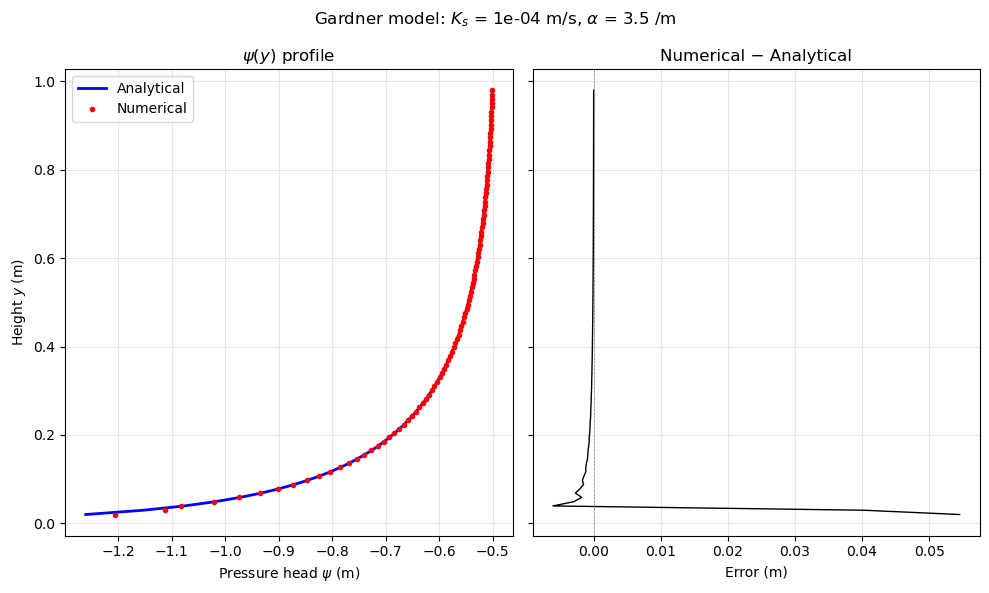

Max absolute error: 5.4541e-02 m


In [10]:
n_sample = 100
sample_y = np.linspace(0.02, COLUMN_HEIGHT - 0.02, n_sample)
sample_x = np.full_like(sample_y, COLUMN_WIDTH / 2)
sample_pts = np.column_stack([sample_x, sample_y])

psi_numerical = uw.function.evaluate(psi_var.sym[0], sample_pts).squeeze()
psi_analytical = gardner_steady_state_psi(
    sample_y, PSI_BOTTOM, PSI_TOP, COLUMN_HEIGHT, ALPHA_G
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Pressure head profile
ax1.plot(psi_analytical, sample_y, "b-", lw=2, label="Analytical")
ax1.plot(psi_numerical, sample_y, "ro", ms=3, label="Numerical")
ax1.set_xlabel(r"Pressure head $\psi$ (m)")
ax1.set_ylabel("Height $y$ (m)")
ax1.set_title(r"$\psi(y)$ profile")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Error
error = psi_numerical - psi_analytical
ax2.plot(error, sample_y, "k-", lw=1)
ax2.axvline(0, color="grey", ls="--", lw=0.5)
ax2.set_xlabel("Error (m)")
ax2.set_title("Numerical − Analytical")
ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Gardner model: $K_s$ = {KS:.0e} m/s, "
    rf"$\alpha$ = {ALPHA_G} /m",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print(f"Max absolute error: {np.max(np.abs(error)):.4e} m")

## Darcy Velocity

The Richards solver also computes the Darcy flux
$\mathbf{q} = -K(\psi)(\nabla\psi - \mathbf{s})$.
At steady state the vertical component should be constant
(uniform flux through the column).

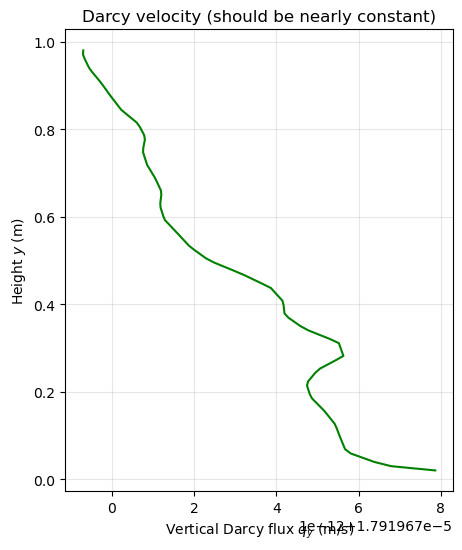

In [11]:
vy_numerical = uw.function.evaluate(v_soln.sym[0, 1], sample_pts).squeeze()

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(vy_numerical, sample_y, "g-", lw=1.5)
ax.set_xlabel(r"Vertical Darcy flux $q_y$ (m/s)")
ax.set_ylabel("Height $y$ (m)")
ax.set_title("Darcy velocity (should be nearly constant)")
ax.grid(True, alpha=0.3)
plt.show()

## Try It Yourself

Experiment with different parameters to build intuition:

```python
# Larger α → sharper transition near saturation
ALPHA_G = 5.0

# Wetter bottom boundary
PSI_BOTTOM = -1.0

# Higher resolution
RES = 64
```

- What happens as $\alpha \to 0$? (Hint: the profile should approach linear.)
- What if the top boundary is fully saturated ($\psi_\text{top} = 0$)?
- The Van Genuchten model is also available — try replacing
  `gardner_K` with `van_genuchten_K` (no analytical solution,
  but the solver still works).
- Can you compute mass conservation by integrating $\theta(\psi)$
  over the column?

## References

Celia, M. A., Bouloutas, E. T. & Zarba, R. L. (1990). A general
mass-conservative numerical solution for the unsaturated flow equation.
*Water Resources Research*, 26(7), 1483–1496.
doi:[10.1029/WR026i007p01483](https://doi.org/10.1029/WR026i007p01483)

Gardner, W. R. (1958). Some steady-state solutions of the unsaturated
moisture flow equation with application to evaporation from a water table.
*Soil Science*, 85(4), 228–232.

Mualem, Y. (1976). A new model for predicting the hydraulic conductivity
of unsaturated porous media. *Water Resources Research*, 12(3), 513–522.
doi:[10.1029/WR012i003p00513](https://doi.org/10.1029/WR012i003p00513)

Richards, L. A. (1931). Capillary conduction of liquids through porous
mediums. *Physics*, 1(5), 318–333.
doi:[10.1063/1.1745010](https://doi.org/10.1063/1.1745010)

Van Genuchten, M. Th. (1980). A closed-form equation for predicting the
hydraulic conductivity of unsaturated soils. *Soil Science Society of
America Journal*, 44(5), 892–898.
doi:[10.2136/sssaj1980.03615995004400050002x](https://doi.org/10.2136/sssaj1980.03615995004400050002x)